In [1]:
%pip install tensorflow keras opencv-python matplotlib scikit-learn albumentations
%pip install requests python-dotenv
%pip install nibabel numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


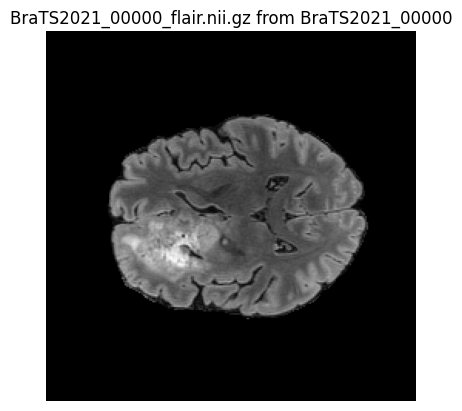

In [2]:
import os
import random
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Define dataset path (where files were extracted)
DATASET_PATH = "./dataset/BraTS2021_Training_Data"

# List all patient folders in the extracted dataset
patient_folders = [f for f in os.listdir(DATASET_PATH) if f.startswith("BraTS2021_")]

# Ensure at least one patient folder is found
if not patient_folders:
    raise FileNotFoundError("No patient folders found in the dataset!")

# Randomly select a patient folder
# random_patient = random.choice(patient_folders)
random_patient = "BraTS2021_00000"
patient_path = os.path.join(DATASET_PATH, random_patient)

# Available MRI modalities (FLAIR, T1, T1CE, T2)
modalities = ["flair", "t1", "t1ce", "t2"]

# Randomly select an MRI modality
# random_modality = f"BraTS2021_{random_patient.split('_')[1]}_{random.choice(modalities)}.nii.gz"
random_modality = "BraTS2021_00000_flair.nii.gz"
mri_path = os.path.join(patient_path, random_modality)

# Check if the file exists
if not os.path.exists(mri_path):
    raise FileNotFoundError(f"MRI file not found: {mri_path}")

# Load and convert NIfTI file to NumPy array
mri_scan = nib.load(mri_path).get_fdata()

# Select a middle slice for visualization
middle_slice = mri_scan.shape[2] // 2
plt.imshow(mri_scan[:, :, middle_slice], cmap='gray')
plt.title(f"{random_modality} from {random_patient}")
plt.axis("off")
plt.show()


2025-12-05 16:44:01.008587: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-05 16:44:01.039919: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 16:44:02.089615: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 16:44:04.121858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Epoch 1/10


/home/vscode/.local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-12-05 16:49:34.501725: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


156/156 ━━━━━━━━━━━━━━━━━━━━ 710s 5s/step - accuracy: 0.7807 - loss: 0.8265
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 56us/step - accuracy: 0.9007 - loss: 0.7903 
Epoch 3/10


/home/vscode/.local/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


156/156 ━━━━━━━━━━━━━━━━━━━━ 725s 5s/step - accuracy: 0.8851 - loss: 0.7434
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 49us/step - accuracy: 0.9006 - loss: 0.7330 
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 706s 5s/step - accuracy: 0.9140 - loss: 0.6895
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 56us/step - accuracy: 0.9563 - loss: 0.4416 
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 715s 5s/step - accuracy: 0.9326 - loss: 0.6516
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 64us/step - accuracy: 0.9427 - loss: 0.5564 
Epoch 9/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 711s 5s/step - accuracy: 0.9388 - loss: 0.6230
Epoch 10/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 76us/step - accuracy: 0.9370 - loss: 0.6890 


✅ Segmentation Model saved successfully!


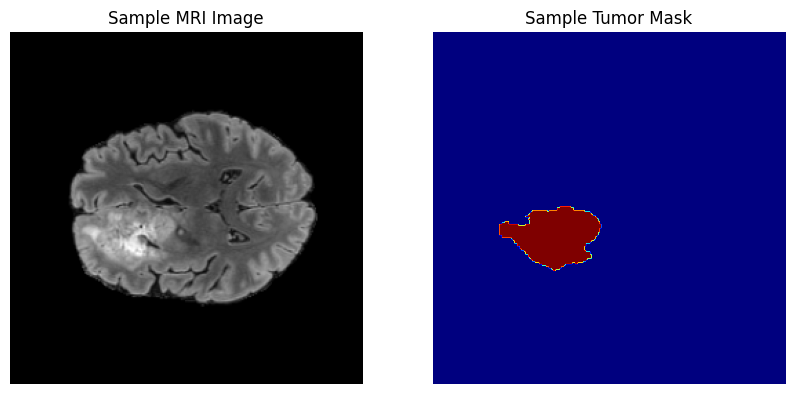

In [3]:
# ✅ STEP 1: Import Necessary Libraries
import os
import numpy as np
import nibabel as nib
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

# ✅ STEP 2: Define Dice Loss (Better for Segmentation)
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# ✅ STEP 3: Define U-Net++ Model
def build_unet_plus_plus(input_shape=(256, 256, 3), num_classes=1):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = BatchNormalization()(c4)

    # Decoder with skip connections
    u3 = UpSampling2D((2, 2))(c4)
    u3 = Concatenate()([u3, c3])
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(u3)
    c5 = BatchNormalization()(c5)

    u2 = UpSampling2D((2, 2))(c5)
    u2 = Concatenate()([u2, c2])
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u2)
    c6 = BatchNormalization()(c6)

    u1 = UpSampling2D((2, 2))(c6)
    u1 = Concatenate()([u1, c1])
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u1)
    c7 = BatchNormalization()(c7)

    outputs = Conv2D(num_classes, (1, 1), activation='sigmoid')(c7)

    return Model(inputs, outputs, name="UNetPlusPlus_Segmentation")

# ✅ STEP 4: Initialize & Compile the Model
unet_model = build_unet_plus_plus()
unet_model.compile(optimizer=Adam(learning_rate=0.0001), loss=dice_loss, metrics=['accuracy'])

# ✅ STEP 5: Load & Preprocess MRI Data from BRaTS 2021 Dataset
DATASET_PATH = "./dataset/BraTS2021_Training_Data"

# Get all patient folders
patient_folders = [f for f in os.listdir(DATASET_PATH) if f.startswith("BraTS2021_")]

# Function to load and preprocess an MRI image
def load_mri_data(patient_folder, modality="flair"):
    mri_path = os.path.join(DATASET_PATH, patient_folder, f"{patient_folder}_{modality}.nii.gz")
    mri_scan = nib.load(mri_path).get_fdata()

    # Select middle slice
    middle_slice = mri_scan.shape[2] // 2
    image = mri_scan[:, :, middle_slice]

    # Resize to 256x256 & normalize
    image_resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
    image_normalized = image_resized / np.max(image_resized)
    image_input = np.stack([image_normalized] * 3, axis=-1)

    return image_input

# Function to load segmentation mask
def load_segmentation_mask(patient_folder):
    mask_path = os.path.join(DATASET_PATH, patient_folder, f"{patient_folder}_seg.nii.gz")
    mask_scan = nib.load(mask_path).get_fdata()

    # Select middle slice
    middle_slice = mask_scan.shape[2] // 2
    mask = mask_scan[:, :, middle_slice]

    # Resize & convert to binary
    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
    mask_binary = np.where(mask_resized > 0, 1, 0)
    mask_input = np.expand_dims(mask_binary, axis=-1)

    return mask_input

# Load MRI images and segmentation masks
X_train, Y_train = [], []
# for patient in patient_folders[:10]:  # Load first 10 patients
for patient in patient_folders:  # Load all patients
    try:
        X_train.append(load_mri_data(patient, modality="flair"))
        Y_train.append(load_segmentation_mask(patient))
    except Exception as e:
        print(f"Error loading patient {patient}: {e}")

X_train = np.array(X_train, dtype="float32")
Y_train = np.array(Y_train, dtype="float32")

# ✅ STEP 6: Apply Data Augmentation
image_gen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.2)
train_generator = image_gen.flow(X_train, Y_train, batch_size=8)

# ✅ STEP 7: Train the Model (Fixed `.repeat()` issue)
steps_per_epoch = max(1, len(X_train) // 8)
history = unet_model.fit(train_generator, epochs=10, steps_per_epoch=steps_per_epoch)

# ✅ STEP 8: Save the Trained Model
unet_model.save("unet_model.h5")
print("✅ Segmentation Model saved successfully!")

# ✅ STEP 9: Visualize Results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_train[0, :, :, 0], cmap='gray')
plt.title("Sample MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Y_train[0, :, :, 0], cmap='jet')
plt.title("Sample Tumor Mask")
plt.axis("off")

plt.show()
